# Notebook 03 — Feature Engineering and Engagement Scoring
# Project: Ad Engagement Analysis
# Goal: Compute a custom mathematically sound engagement metric for distinct ads.

## Methodology
The final deliverable incorporates creating a single continuous engagement metric combining qualitative metrics via NLP and quantitative metrics (comments, emojis, hashtags). 

Calculates:
- Positive Sentiment bonus (+0.5 multiplier)
- Emoji factor indicating deeper qualitative engagement
- Hashtag count multiplier

Ranking of specific entities/content pieces evaluates the highest overall user resonance.

In [1]:
import pandas as pd
import numpy as np
from textblob import TextBlob
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

try:
    df = pd.read_csv('../data/comments_cleaned.csv')
    print("Dataset loaded successfully.")
except FileNotFoundError:
    import sys
    print("Dataset not found.")
    sys.exit(1)

df['comment'] = df['comment'].astype(str)
df['sentiment_score'] = df['comment'].apply(lambda x: TextBlob(x).sentiment.polarity)

df['emoji value'] = df['emoji used'].map({'yes': 1.5, 'no': 1.0})
df['emoji value'].fillna(1.0, inplace=True) 

df['comment_length'] = df['comment'].str.len()

display(df.head())

Dataset loaded successfully.


,Unnamed: 0,id,comment,User id,Photo id,created Timestamp,posted date,emoji used,Hashtags used count,sentiment_score,emoji value,comment_length
0,0,1,fantastic. wonderful experience.,2,1,13-04-2023 08:04,April 14,yes,1,0.700,1.5,32
1,1,2,broke easily. awful.,3,1,13-04-2023 08:04,April 14,no,2,-1.000,1.0,20
2,2,3,met expectations. five stars.,5,1,13-04-2023 08:04,April 14,no,4,0.000,1.0,29
3,3,4,very satisfied. wonderful experience.,14,1,13-04-2023 08:04,April 14,yes,2,0.825,1.5,37
4,4,5,worst purchase. one star.,17,1,13-04-2023 08:04,April 14,yes,1,-1.000,1.5,25


## 1. Feature Engineering: The Components
Aggregating the metrics into individual multiplier columns.

In [2]:
df['sentiment_multiplier'] = df['sentiment_score'].apply(lambda x: 1 + x if x > 0 else 0.5 + x if x < 0 else 1)

df['Engagement Score'] = (
    (df['comment_length'] * 0.1) +
    (df['Hashtags used count'] * 2) 
) * df['emoji value'] * df['sentiment_multiplier']

display(df[['id', 'comment_length', 'Hashtags used count', 'emoji value', 'sentiment_multiplier', 'Engagement Score']].head(10))

,id,comment_length,Hashtags used count,emoji value,sentiment_multiplier,Engagement Score
0,1,32,1,1.5,1.700000,13.260000
1,2,20,2,1.0,-0.500000,-3.000000
2,3,29,4,1.0,1.000000,10.900000
3,4,37,2,1.5,1.825000,21.078750
4,5,25,1,1.5,-0.500000,-3.375000
5,6,36,2,1.0,2.000000,15.200000
6,7,35,0,1.5,1.380000,7.245000
7,8,29,5,1.0,0.200000,2.580000
8,9,53,6,1.0,1.339048,23.165524
9,10,29,2,1.5,-0.200000,-2.070000


## 2. Computing Engagement Scores and Ranking Entities
Plotting the aggregate Engagement Scores against original IDs to determine winners.

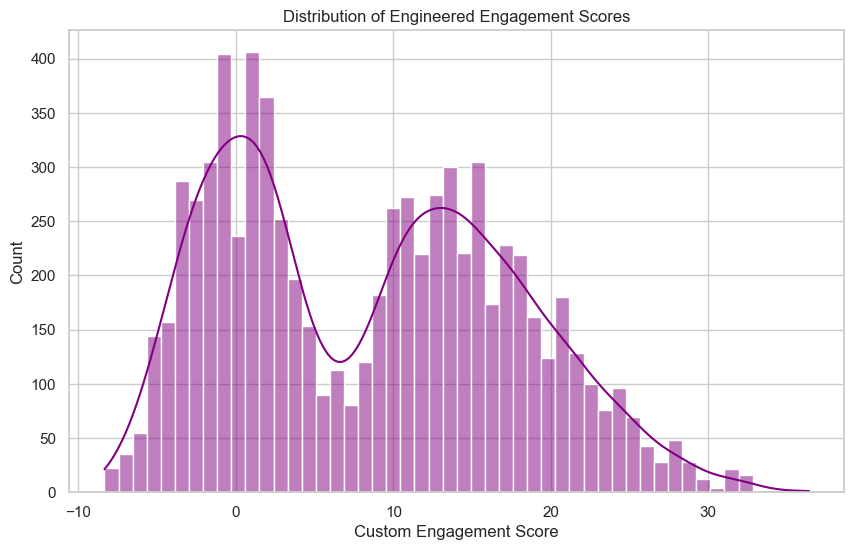


--- Summary of Engagement Matrix ---
count    7488.000000
mean        8.469949
std         9.118620
min        -8.350000
25%         0.455000
50%         8.917500
75%        15.448750
max        36.400000
Name: Engagement Score, dtype: float64

--- Identifying High-Impact Content ---
Top 5 Image Entities Driven by Metric:
     Photo id  Engagement Score
136       137         11.999276
203       204         11.762091
192       193         11.735259
178       179         11.593722
237       238         11.540120


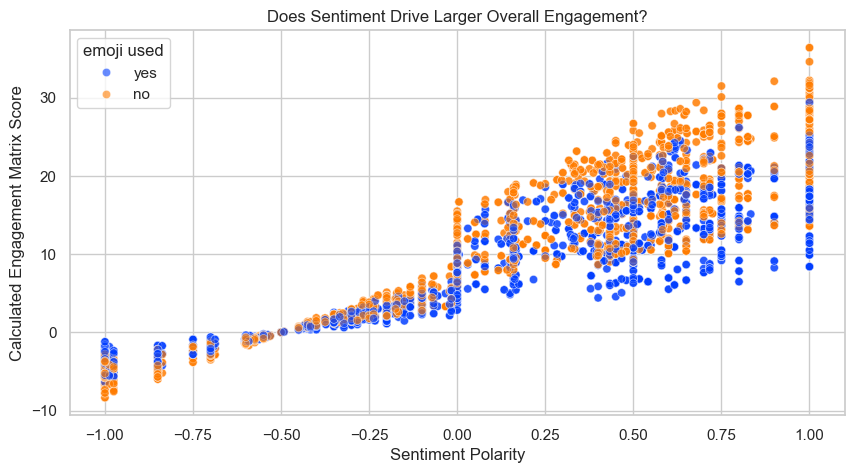

In [3]:
plt.figure(figsize=(10,6))
sns.histplot(df['Engagement Score'], bins=50, color='purple', kde=True)
plt.title('Distribution of Engineered Engagement Scores')
plt.xlabel('Custom Engagement Score')
plt.show()

print("\n--- Summary of Engagement Matrix ---")
print(df['Engagement Score'].describe())

top_ads = df.groupby('Photo id')['Engagement Score'].mean().reset_index()
top_ads = top_ads.sort_values(by='Engagement Score', ascending=False)

print("\n--- Identifying High-Impact Content ---")
print("Top 5 Image Entities Driven by Metric:")
print(top_ads.head())

plt.figure(figsize=(10,5))
sns.scatterplot(x='sentiment_score', y='Engagement Score', data=df, hue='emoji used', alpha=0.6, palette='bright')
plt.title('Does Sentiment Drive Larger Overall Engagement?')
plt.xlabel('Sentiment Polarity')
plt.ylabel('Calculated Engagement Matrix Score')
plt.show()